## AOS C111 Final Project: Analyzing the AR IVT-Precipitation Relationship with Machine Learning
### Emilio Yanez Jr.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Import AR data
# Note: I will provide these two .txt files on my Github, so you can reproduce the results
from google.colab import drive
drive.mount('/content/drive')
filepath = '/content/drive/MyDrive/NH_NDJFM_ARs_01_th_f.txt'
filepath2 = '/content/drive/MyDrive/NH_MJJAS_ARs_01_th_f.txt'

#AR_all = np.genfromtxt(filepath)

AR_all_NDJFM = pd.read_csv(filepath, sep = '\t', skiprows = 1,
                           names = ['AR Mean Wind (m/s)', 'AR Mean IWV (kg/m2)', 'AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', 'Central Lons (deg)', 'Central Lats (deg)'])
AR_all_MJJAS = pd.read_csv(filepath2, sep = '\t', skiprows = 1,
                           names = ['AR Mean Wind (m/s)', 'AR Mean IWV (kg/m2)', 'AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', 'Central Lons (deg)', 'Central Lats (deg)'])

Mounted at /content/drive


In [45]:
AR_all_NDJFM.head()

,AR Mean Wind (m/s),AR Mean IWV (kg/m2),AR Mean IVT (kg/m/s),AR Mean Precip (mm/day),Central Lons (deg),Central Lats (deg)
0,11.955742,41.201134,467.200958,12.655289,264.905,21.200
1,10.812697,22.832947,229.755142,4.286365,43.350,26.029
2,21.365599,30.414259,522.013306,15.923621,136.535,30.678
3,16.168025,11.211940,157.911865,1.953020,76.008,65.506
4,19.779290,17.559341,275.033691,24.203941,338.180,59.712


In [4]:
## Look at a Covariance Matrix to get an idea of which variables may best predict precipitation
# Scale the data (using Standard Scaler)
from sklearn.preprocessing import StandardScaler
scaler_input = StandardScaler()
scaler_input.fit(AR_all_NDJFM)
AR_all_NDJFM_scaled = scaler_input.transform(AR_all_NDJFM)

# Putting the scaled data back into a dataframe
AR_all_NDJFM_scaled = pd.DataFrame(AR_all_NDJFM_scaled)
AR_all_NDJFM_scaled.index = AR_all_NDJFM.index
mapcols = {}
for idx in range(len(AR_all_NDJFM.columns)):
    mapcols[idx] = AR_all_NDJFM.columns[idx]
AR_all_NDJFM_scaled = AR_all_NDJFM_scaled.rename(columns=mapcols)

AR_all_NDJFM_scaled.cov()

,AR Mean Wind (m/s),AR Mean IWV (kg/m2),AR Mean IVT (kg/m/s),AR Mean Precip (mm/day),Central Lons (deg),Central Lats (deg)
AR Mean Wind (m/s),1.000087,-0.257864,0.374419,0.251131,0.237098,0.346381
AR Mean IWV (kg/m2),-0.257864,1.000087,0.753615,0.415717,0.228003,-0.718980
AR Mean IVT (kg/m/s),0.374419,0.753615,1.000087,0.555066,0.377209,-0.434040
AR Mean Precip (mm/day),0.251131,0.415717,0.555066,1.000087,0.341278,-0.089155
Central Lons (deg),0.237098,0.228003,0.377209,0.341278,1.000087,-0.007266
Central Lats (deg),0.346381,-0.718980,-0.434040,-0.089155,-0.007266,1.000087


In [5]:
# Extract Variables of Interest
NDJFM_AR_wind = AR_all_NDJFM['AR Mean Wind (m/s)']
NDJFM_AR_IWV = AR_all_NDJFM['AR Mean IWV (kg/m2)']
NDJFM_AR_precip = AR_all_NDJFM['AR Mean Precip (mm/day)']
NDJFM_AR_IVT = AR_all_NDJFM['AR Mean IVT (kg/m/s)']
NDJFM_AR_cen_lats = AR_all_NDJFM['Central Lats (deg)']
NDJFM_AR_cen_lons = AR_all_NDJFM['Central Lons (deg)']

MJJAS_AR_wind = AR_all_MJJAS['AR Mean Wind (m/s)']
MJJAS_AR_IWV = AR_all_MJJAS['AR Mean IWV (kg/m2)']
MJJAS_AR_precip = AR_all_MJJAS['AR Mean Precip (mm/day)']
MJJAS_AR_IVT = AR_all_MJJAS['AR Mean IVT (kg/m/s)']
MJJAS_AR_cen_lats = AR_all_MJJAS['Central Lats (deg)']
MJJAS_AR_cen_lons = AR_all_MJJAS['Central Lons (deg)']

Previous work analyzed the AR IVT-precipitation relationship using conditional (binned scatter) methods. The relationship is overall linear, and IVT seems to be a good predictor of an AR's precipitation. How well do ML methods replicate this conditional relationship?

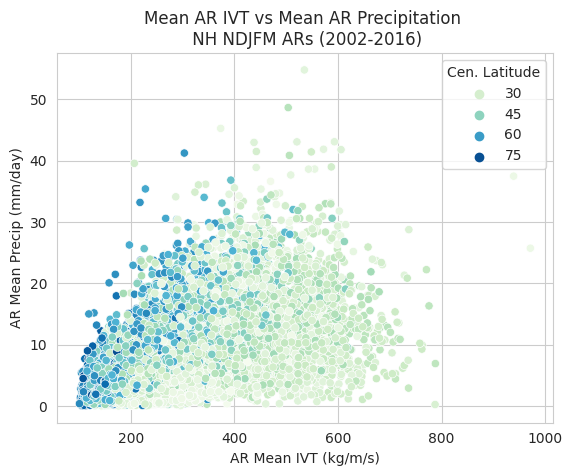

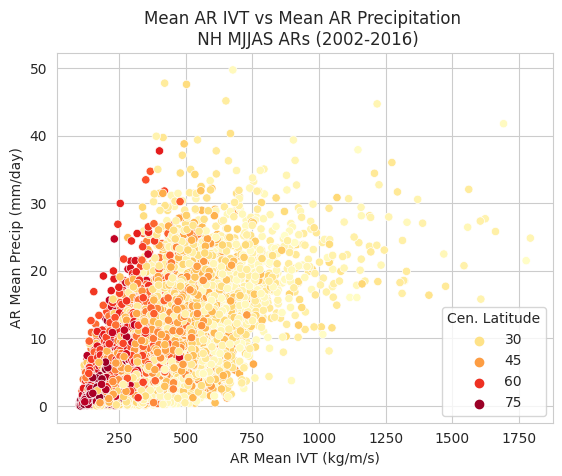

In [6]:
# Plot Raw AR IVT vs AR Precip
sns.set_style('whitegrid')
sns.scatterplot(x = NDJFM_AR_IVT, y = NDJFM_AR_precip, hue = NDJFM_AR_cen_lats, palette = 'GnBu', alpha = 1, sizes = 1)
plt.title('Mean AR IVT vs Mean AR Precipitation \n NH NDJFM ARs (2002-2016)')
plt.legend(title = 'Cen. Latitude')

plt.show()

sns.set_style('whitegrid')
sns.scatterplot(x = MJJAS_AR_IVT, y = MJJAS_AR_precip, hue = MJJAS_AR_cen_lats, palette = 'YlOrRd', alpha = 1, sizes = 1)
plt.title('Mean AR IVT vs Mean AR Precipitation \n NH MJJAS ARs (2002-2016)')
plt.legend(title = 'Cen. Latitude')

plt.show()

### Linear Regression Model (with Regularization)

In [7]:
# First split the data into test and training
from sklearn.model_selection import train_test_split

# For NDJFM
X_data = AR_all_NDJFM.drop(['AR Mean Precip (mm/day)'], axis = 1).values
y_data = AR_all_NDJFM['AR Mean Precip (mm/day)'].values
y_data = y_data.reshape(-1,1) # Makes into matrix rather than array (for later)

# For MJJAS
X_data2 = AR_all_MJJAS.drop(['AR Mean Precip (mm/day)'], axis = 1).values
y_data2 = AR_all_MJJAS['AR Mean Precip (mm/day)'].values
y_data2 = y_data2.reshape(-1,1)

test_size = 0.3
# NDJFM split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state = 14) # Number doesn't matter, but keep it the same for reproducability
# MJJAS split
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_data2, y_data2, test_size=test_size, random_state = 14)

In [8]:
# Double check...
AR_all_NDJFM.drop(['AR Mean Precip (mm/day)'], axis = 1).head()

,AR Mean Wind (m/s),AR Mean IWV (kg/m2),AR Mean IVT (kg/m/s),Central Lons (deg),Central Lats (deg)
0,11.955742,41.201134,467.200958,264.905,21.200
1,10.812697,22.832947,229.755142,43.350,26.029
2,21.365599,30.414259,522.013306,136.535,30.678
3,16.168025,11.211940,157.911865,76.008,65.506
4,19.779290,17.559341,275.033691,338.180,59.712


In [9]:
# Linear Model
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# NDJFM ARs
# Use a pipeline with standard scaler:
pipe = Pipeline([('scaler', StandardScaler()), ('lr', Ridge(alpha=1.0, random_state = 14))])
pipe.fit(X_train, y_train)
y_pred_lr = pipe.predict(X_test)

# MJJAS ARs
# Use a pipeline with standard scaler (can use same as above):
pipe.fit(X_train2, y_train2)
y_pred_lr_2 = pipe.predict(X_test2)

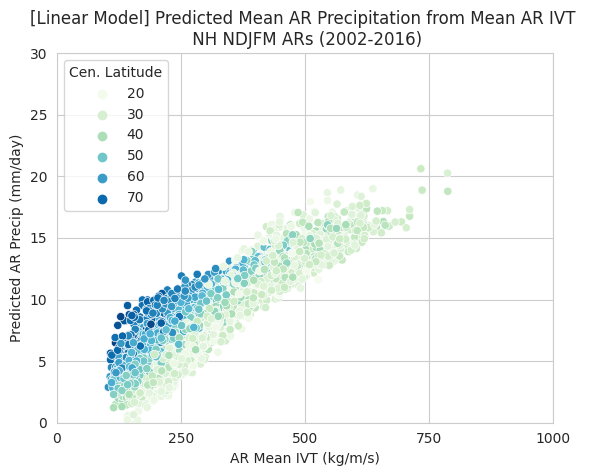

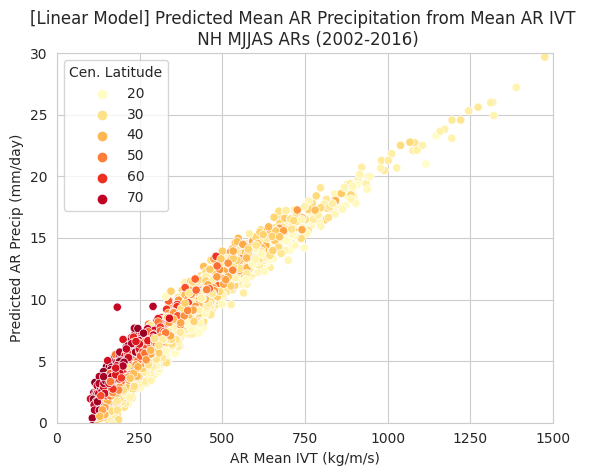

In [10]:
## Plot results
# NDJFM
sns.set_style('whitegrid')
sns.scatterplot(x = X_test[:,2], y = y_pred_lr.flatten(), hue = X_test[:,4], palette = 'GnBu', alpha = 1, sizes = 1)
plt.xlabel('AR Mean IVT (kg/m/s)'), plt.ylabel('Predicted AR Precip (mm/day)')
plt.title('[Linear Model] Predicted Mean AR Precipitation from Mean AR IVT \n NH NDJFM ARs (2002-2016)')
plt.xticks([0, 250, 500, 750, 1000])
plt.xlim(0,1000), plt.ylim(0, 30)
plt.legend(title = 'Cen. Latitude')

plt.show()

# MJJAS
sns.set_style('whitegrid')
sns.scatterplot(x = X_test2[:,2], y = y_pred_lr_2.flatten(), hue = X_test2[:,4], palette = 'YlOrRd', alpha = 1, sizes = 1)
plt.xlabel('AR Mean IVT (kg/m/s)'), plt.ylabel('Predicted AR Precip (mm/day)')
plt.title('[Linear Model] Predicted Mean AR Precipitation from Mean AR IVT \n NH MJJAS ARs (2002-2016)')
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.xlim(0,1500), plt.ylim(0, 30)
plt.legend(title = 'Cen. Latitude')

plt.show()

### Support Vector Regression

In [11]:
# SVR Model
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# NDJFM
# Still want to use standard scaler
# Fit the model (Note: Can tweak C, regularization parameter; and epsilon, 'penalty tube')
SVR_regr = make_pipeline(StandardScaler(), SVR(C=1, epsilon = 0.01))
SVR_regr.fit(X_train, y_train.ravel()) #.ravel() reshapes to a 1d array
# Test the model
SVR_y_pred = SVR_regr.fit(X_test, y_test.ravel()).predict(X_test)

# MJJAS
# Fit the model
SVR_regr2 = make_pipeline(StandardScaler(), SVR(C=1, epsilon = 0.01))
SVR_regr2.fit(X_train2, y_train2.ravel())
# Test the model
SVR_y_pred2 = SVR_regr2.fit(X_test2, y_test2.ravel()).predict(X_test2)

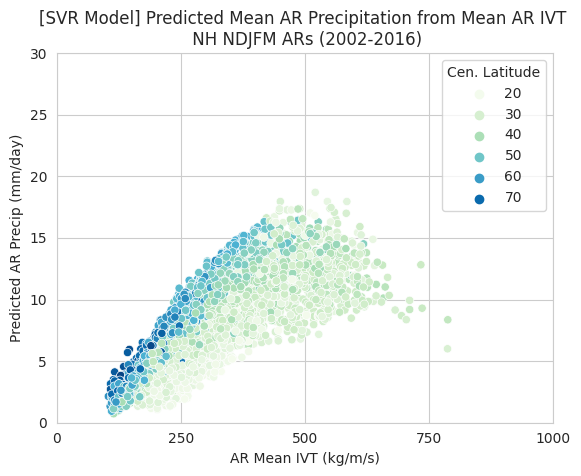

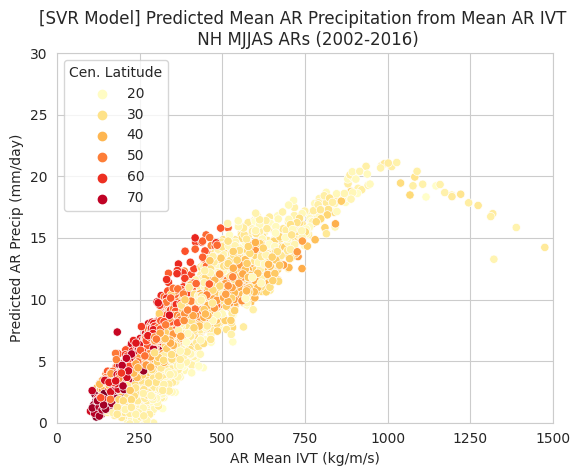

In [12]:
## Plot the results
# NDJFM
sns.set_style('whitegrid')
sns.scatterplot(x = X_test[:,2], y = SVR_y_pred.flatten(), hue = X_test[:,4], palette = 'GnBu', alpha = 1, sizes = 1)
plt.legend(title = 'Cen. Latitude')
plt.xlabel('AR Mean IVT (kg/m/s)'), plt.ylabel('Predicted AR Precip (mm/day)')
plt.title('[SVR Model] Predicted Mean AR Precipitation from Mean AR IVT \n NH NDJFM ARs (2002-2016)')
plt.xticks([0, 250, 500, 750, 1000])
plt.xlim(0,1000), plt.ylim(0,30)

plt.show()

# MJJAS
sns.set_style('whitegrid')
sns.scatterplot(x = X_test2[:,2], y = SVR_y_pred2.flatten(), hue = X_test2[:,4], palette = 'YlOrRd', alpha = 1, sizes = 1)
plt.legend(title = 'Cen. Latitude')
plt.xlabel('AR Mean IVT (kg/m/s)'), plt.ylabel('Predicted AR Precip (mm/day)')
plt.title('[SVR Model] Predicted Mean AR Precipitation from Mean AR IVT \n NH MJJAS ARs (2002-2016)')
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.xlim(0,1500), plt.ylim(0,30)

plt.show()

### Random Forest Regression

In [13]:
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

# NDJFM
# Create a random forest:
regr_rf = RandomForestRegressor(n_estimators=100, max_depth=10, oob_score = True, random_state = 14)
# Fit the model:
regr_rf.fit(X_data, y_data)
# Test the model:
y_test_rf = regr_rf.predict(X_test)

# MJJAS
# Create a random forest:
regr_rf_2 = RandomForestRegressor(n_estimators=100, max_depth=10, oob_score = True, random_state = 14)
# Fit the model:
regr_rf_2.fit(X_data2, y_data2)
# Test the model:
y_test_rf_2 = regr_rf_2.predict(X_test2)

<ipython-input-13-7b373cf2869b>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  regr_rf.fit(X_data, y_data)
<ipython-input-13-7b373cf2869b>:16: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  regr_rf_2.fit(X_data2, y_data2)


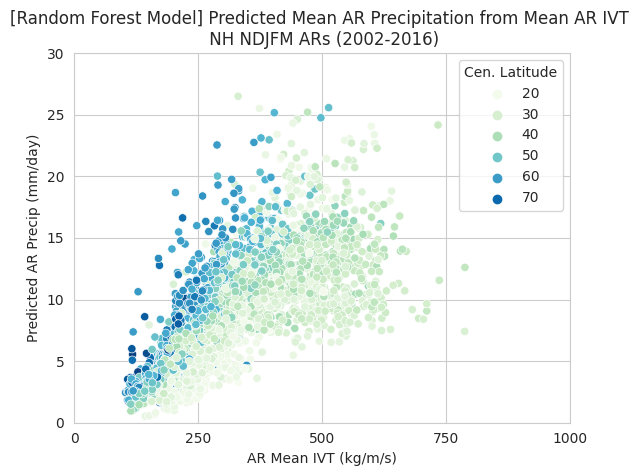

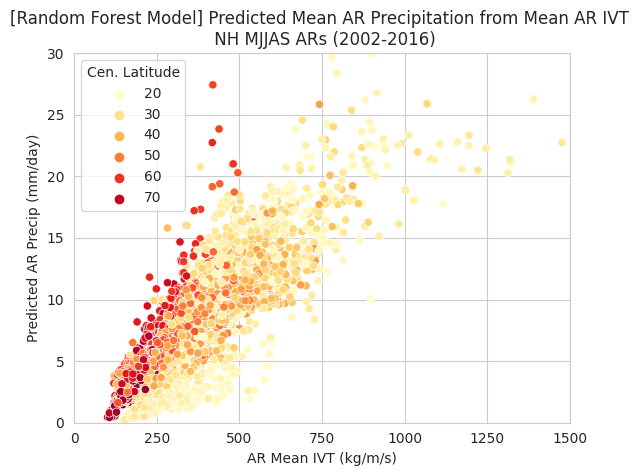

In [14]:
## Plot the results:
# NDJFM
sns.scatterplot(x = X_test[:,2], y = y_test_rf.flatten(), hue = X_test[:,4], palette = 'GnBu', alpha = 1, sizes = 1)
plt.xlabel('AR Mean IVT (kg/m/s)'), plt.ylabel('Predicted AR Precip (mm/day)')
plt.title("[Random Forest Model] Predicted Mean AR Precipitation from Mean AR IVT \n NH NDJFM ARs (2002-2016)")
plt.xlim(0,1000), plt.ylim(0,30)
plt.xticks([0, 250, 500, 750, 1000])
plt.legend(title = 'Cen. Latitude')
plt.show()

# MJJAS
sns.scatterplot(x = X_test2[:,2], y = y_test_rf_2.flatten(), hue = X_test2[:,4], palette = 'YlOrRd', alpha = 1, sizes = 1)
plt.xlabel('AR Mean IVT (kg/m/s)'), plt.ylabel('Predicted AR Precip (mm/day)')
plt.title("[Random Forest Model] Predicted Mean AR Precipitation from Mean AR IVT \n NH MJJAS ARs (2002-2016)")
plt.xlim(0,1500), plt.ylim(0,30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.legend(title = 'Cen. Latitude')
plt.show()

Feature ranking:
1. feature 2 (0.560421)
2. feature 4 (0.149987)
3. feature 3 (0.131685)
4. feature 1 (0.103578)
5. feature 0 (0.054329)


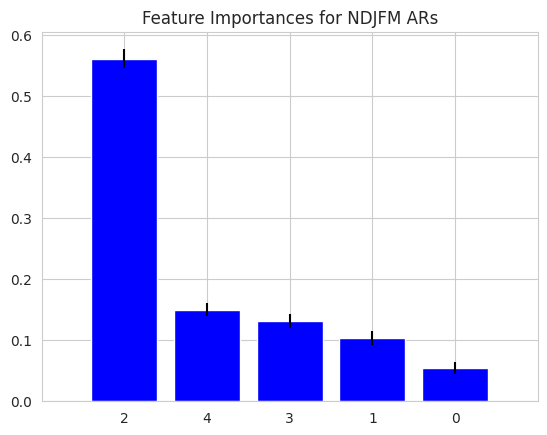

In [15]:
# (Extra) Calculate the importance of each feature
# Source: AOS C111 HW 4

# For NDJFM
importances = regr_rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in regr_rf.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

#print the feature ranking
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

#plot the impurity-based feature importances of the forest
plt.figure()
plt.title("Feature Importances for NDJFM ARs")
plt.bar(range(X_train.shape[1]), importances[indices],
        color="b", yerr=std[indices], align="center")
plt.xticks(range(X_train.shape[1]), indices)
plt.xlim([-1, X_train.shape[1]])
plt.show()

Feature ranking:
1. feature 2 (0.616005)
2. feature 3 (0.152313)
3. feature 4 (0.099610)
4. feature 1 (0.079492)
5. feature 0 (0.052579)


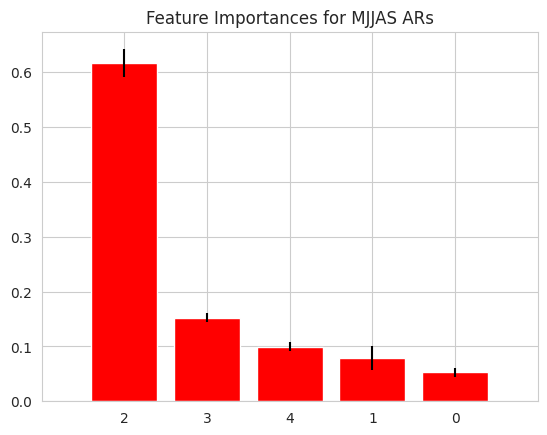

In [16]:
# For MJJAS
importances = regr_rf_2.feature_importances_
std = np.std([tree.feature_importances_ for tree in regr_rf_2.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

#print the feature ranking
print("Feature ranking:")
for f in range(X_train2.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

#plot the impurity-based feature importances of the forest
plt.figure()
plt.title("Feature Importances for MJJAS ARs")
plt.bar(range(X_train2.shape[1]), importances[indices],
        color="r", yerr=std[indices], align="center")
plt.xticks(range(X_train2.shape[1]), indices)
plt.xlim([-1, X_train2.shape[1]])
plt.show()

This gives even more evidence that Feature 2 (AR IVT) is the most important predictor for AR precipitation.

____
## Conditional Means: Comparison Between Non-ML and ML Methods
### Conditional Means for Non-ML Method (existing research)

In [21]:
# Binsreg native to R, developed by Cattaneo, Crump, Farrell, Feng (2021).
# Function modified by M. Courthoud

!pip install binsreg # Uncomment if need to download
import binsreg

def binscatter(**kwargs):
    # Estimate binsreg
    est = binsreg.binsreg(**kwargs)

    # Retrieve estimates
    df_est = pd.concat([d.dots for d in est.data_plot])
    df_est = df_est.rename(columns={'x': kwargs.get("x"), 'fit': kwargs.get("y")})

    # Add confidence intervals
    if "ci" in kwargs:
        df_est = pd.merge(df_est, pd.concat([d.ci for d in est.data_plot]))
        df_est = df_est.drop(columns=['x'])
        df_est['ci'] = df_est['ci_r'] - df_est['ci_l']

    # Rename groups
    if "by" in kwargs:
        df_est['group'] = df_est['group'].astype(df[kwargs.get("by")].dtype)
        df_est = df_est.rename(columns={'group': kwargs.get("by")})

    return df_est

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 892.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 58.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.8/341.8 kB 28.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires kaleido, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.
google-colab 1.0.0 requires pandas==1.5.3, but you have pandas 2.1.3 which is incompatible.


In [22]:
# Condtional Mean for AR IVT-Precip
AR_NH_NDJFM_IVT_precip_conditional_mean = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = AR_all_NDJFM, ci = (3,3), noplot = True)
AR_NH_MJJAS_IVT_precip_conditional_mean = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = AR_all_MJJAS, ci = (3,3), noplot = True)


/usr/local/lib/python3.10/dist-packages/binsreg/binsreg.py:783: UserWarning: To speed up computation, bin/degree selection uses a subsample of roughly max(5,000, 0.01n) observations if the sample size n>5,000. To use the full sample, set randcut=1.
/usr/local/lib/python3.10/dist-packages/binsreg/binsreg.py:783: UserWarning: To speed up computation, bin/degree selection uses a subsample of roughly max(5,000, 0.01n) observations if the sample size n>5,000. To use the full sample, set randcut=1.


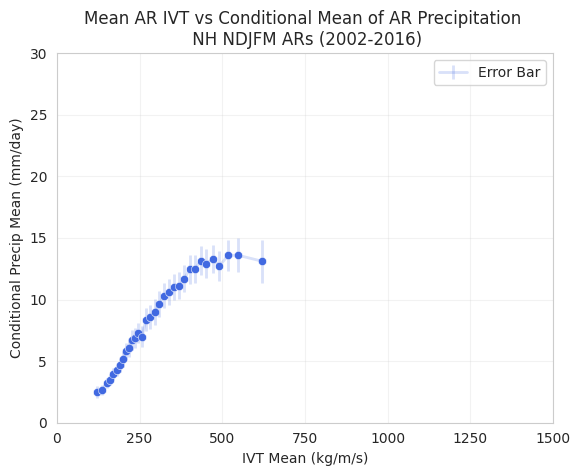

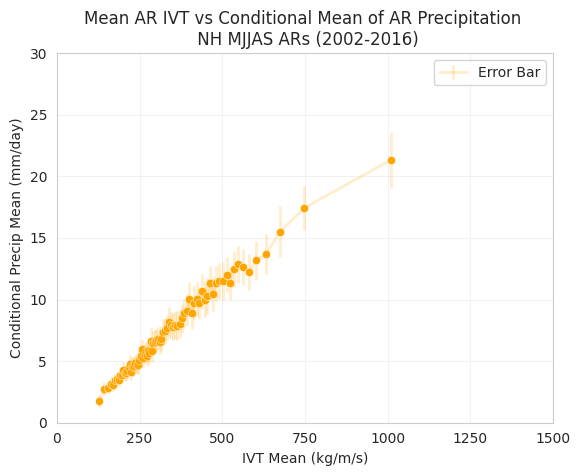

In [23]:
# Conditional Mean of Precip
# NH NDJFM ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean, color = 'royalblue')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_NDJFM_IVT_precip_conditional_mean, color = 'royalblue', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('Mean AR IVT vs Conditional Mean of AR Precipitation \n NH NDJFM ARs (2002-2016)')
plt.legend()

plt.show()

# NH MJJAS ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean, color = 'orange')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_MJJAS_IVT_precip_conditional_mean, color = 'orange', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('Mean AR IVT vs Conditional Mean of AR Precipitation \n NH MJJAS ARs (2002-2016)')
plt.legend()

plt.show()

### Conditional Means for Linear Regression Model

In [24]:
# Make dataframes
NDJFM_AR_linear_df = pd.DataFrame(data = [X_test[:,2], y_pred_lr.flatten()], index = ['AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)']).T
MJJAS_AR_linear_df = pd.DataFrame(data = [X_test2[:,2], y_pred_lr_2.flatten()], index = ['AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)']).T

In [25]:
# Condtional Mean for AR IVT-Precip, Linear Model
AR_NH_NDJFM_IVT_precip_conditional_mean_lin = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = NDJFM_AR_linear_df, ci = (3,3), noplot = True)
AR_NH_MJJAS_IVT_precip_conditional_mean_lin = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = MJJAS_AR_linear_df, ci = (3,3), noplot = True)

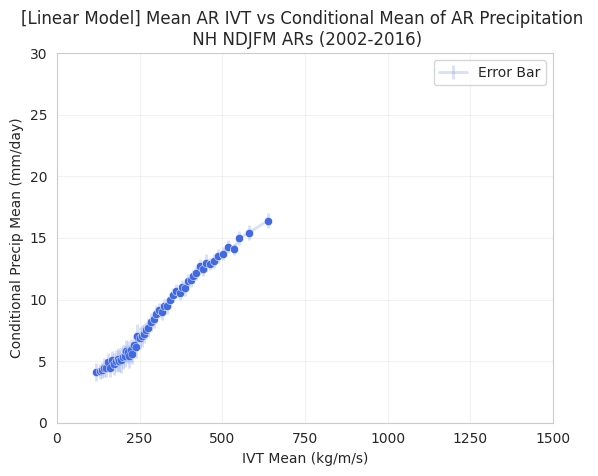

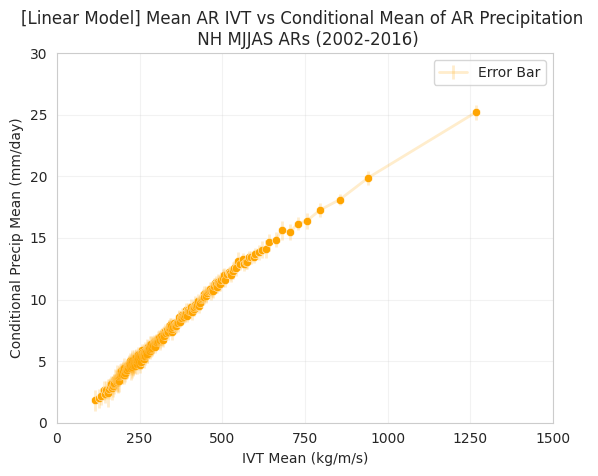

In [26]:
# Conditional Mean of Precip
# NH NDJFM ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean_lin, color = 'royalblue')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_NDJFM_IVT_precip_conditional_mean_lin, color = 'royalblue', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('[Linear Model] Mean AR IVT vs Conditional Mean of AR Precipitation \n NH NDJFM ARs (2002-2016)')
plt.legend()

plt.show()

# NH MJJAS ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean_lin, color = 'orange')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_MJJAS_IVT_precip_conditional_mean_lin, color = 'orange', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('[Linear Model] Mean AR IVT vs Conditional Mean of AR Precipitation \n NH MJJAS ARs (2002-2016)')
plt.legend()

plt.show()

### Conditional Means for SVR Model

In [27]:
# Make dataframes
NDJFM_AR_SVR_df = pd.DataFrame(data = [X_test[:,2], SVR_y_pred.flatten()], index = ['AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)']).T
MJJAS_AR_SVR_df = pd.DataFrame(data = [X_test2[:,2], SVR_y_pred2.flatten()], index = ['AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)']).T

In [28]:
# Condtional Mean for AR IVT-Precip, SVR Model
AR_NH_NDJFM_IVT_precip_conditional_mean_SVR = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = NDJFM_AR_SVR_df, ci = (3,3), noplot = True)
AR_NH_MJJAS_IVT_precip_conditional_mean_SVR = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = MJJAS_AR_SVR_df, ci = (3,3), noplot = True)

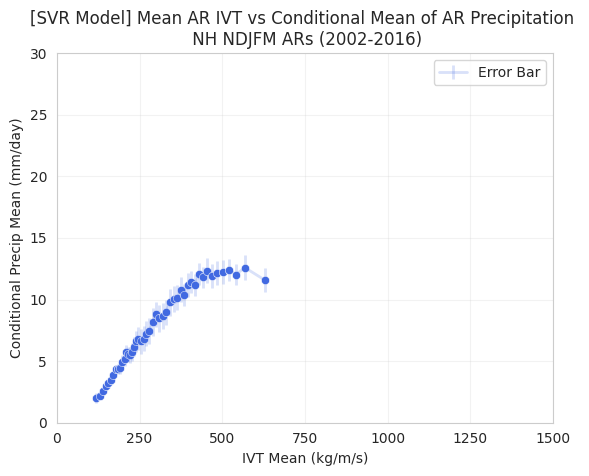

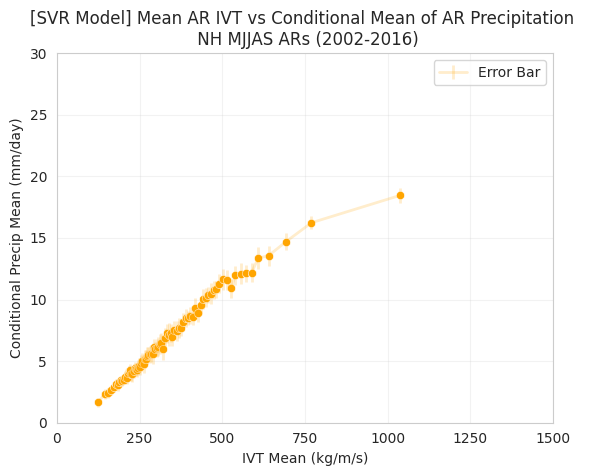

In [29]:
# Conditional Mean of Precip
# NH NDJFM ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean_SVR, color = 'royalblue')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_NDJFM_IVT_precip_conditional_mean_SVR, color = 'royalblue', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('[SVR Model] Mean AR IVT vs Conditional Mean of AR Precipitation \n NH NDJFM ARs (2002-2016)')
plt.legend()

plt.show()

# NH MJJAS ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean_SVR, color = 'orange')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_MJJAS_IVT_precip_conditional_mean_SVR, color = 'orange', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('[SVR Model] Mean AR IVT vs Conditional Mean of AR Precipitation \n NH MJJAS ARs (2002-2016)')
plt.legend()

plt.show()

### Coditional Means for Random Forest Model

In [30]:
# Make dataframes
NDJFM_AR_rf_df = pd.DataFrame(data = [X_test[:,2], y_test_rf.flatten()], index = ['AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)']).T
MJJAS_AR_rf_df = pd.DataFrame(data = [X_test2[:,2], y_test_rf_2.flatten()], index = ['AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)']).T

In [31]:
# Condtional Mean for AR IVT-Precip, Random Forest Model
AR_NH_NDJFM_IVT_precip_conditional_mean_rf = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = NDJFM_AR_rf_df, ci = (3,3), noplot = True)
AR_NH_MJJAS_IVT_precip_conditional_mean_rf = binscatter(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)', data = MJJAS_AR_rf_df, ci = (3,3), noplot = True)

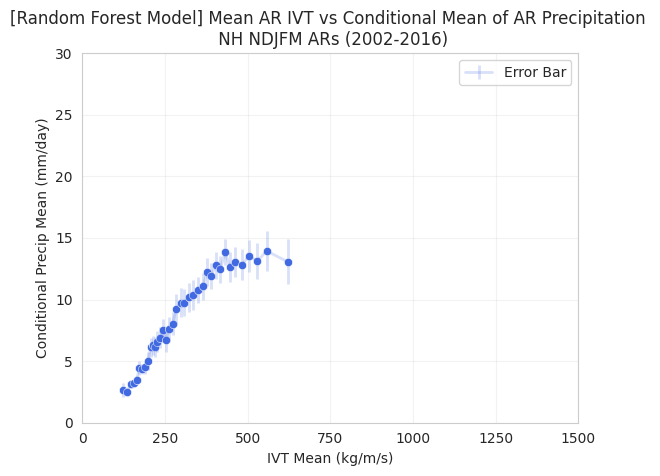

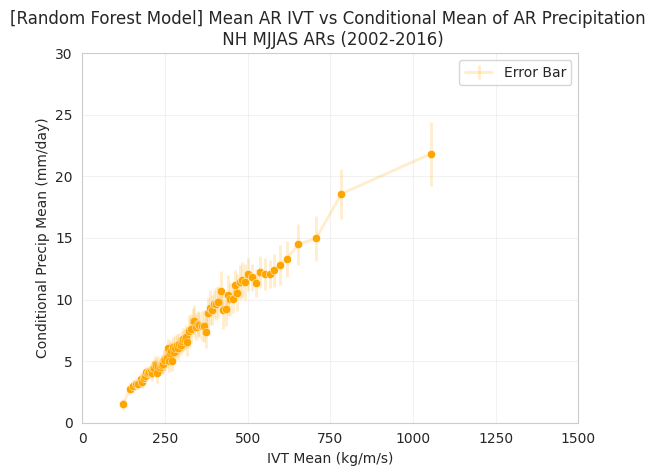

In [32]:
# Conditional Mean of Precip
# NH NDJFM ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean_rf, color = 'royalblue')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_NDJFM_IVT_precip_conditional_mean_rf, color = 'royalblue', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('[Random Forest Model] Mean AR IVT vs Conditional Mean of AR Precipitation \n NH NDJFM ARs (2002-2016)')
plt.legend()

plt.show()

# NH MJJAS ARs
sns.scatterplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean_rf, color = 'orange')
plt.errorbar('AR Mean IVT (kg/m/s)', 'AR Mean Precip (mm/day)', yerr = 'ci',
             data = AR_NH_MJJAS_IVT_precip_conditional_mean_rf, color = 'orange', ls = '-', lw = 2, alpha = 0.2, label = 'Error Bar')
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
plt.xlim(0, 1500), plt.ylim(0, 30)
plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('[Random Forest Model] Mean AR IVT vs Conditional Mean of AR Precipitation \n NH MJJAS ARs (2002-2016)')
plt.legend()

plt.show()

### Comparison of Non-ML and ML Methods

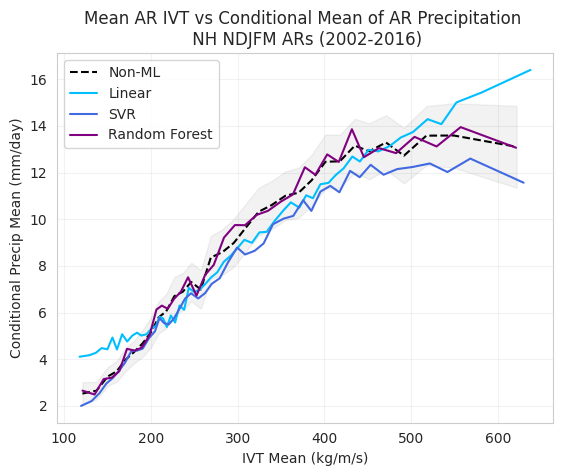

In [42]:
## Scatterplot for NDJFM ARs
# Non-ML
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean, color = 'black', label = 'Non-ML', ls = '--')
plt.fill_between(AR_NH_NDJFM_IVT_precip_conditional_mean['AR Mean IVT (kg/m/s)'],
                 AR_NH_NDJFM_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean['ci'],
                 AR_NH_NDJFM_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] + AR_NH_NDJFM_IVT_precip_conditional_mean['ci'],
                 color = 'black', alpha = 0.05)

# Linear Model
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean_lin, color = 'deepskyblue', label = 'Linear')
#plt.fill_between(AR_NH_NDJFM_IVT_precip_conditional_mean_lin['AR Mean IVT (kg/m/s)'],
#                 AR_NH_NDJFM_IVT_precip_conditional_mean_lin['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean_lin['ci'],
#                 AR_NH_NDJFM_IVT_precip_conditional_mean_lin['AR Mean Precip (mm/day)'] + AR_NH_NDJFM_IVT_precip_conditional_mean_lin['ci'],
#                 color = 'deepskyblue', alpha = 0.1)

# SVR
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean_SVR, color = 'royalblue', label = 'SVR')
#plt.fill_between(AR_NH_NDJFM_IVT_precip_conditional_mean_SVR['AR Mean IVT (kg/m/s)'],
#                 AR_NH_NDJFM_IVT_precip_conditional_mean_SVR['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean_SVR['ci'],
#                 AR_NH_NDJFM_IVT_precip_conditional_mean_SVR['AR Mean Precip (mm/day)'] + AR_NH_NDJFM_IVT_precip_conditional_mean_SVR['ci'],
#                 color = 'royalblue', alpha = 0.1)

# Random Forest
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_NDJFM_IVT_precip_conditional_mean_rf, color = 'purple', label = 'Random Forest')
#plt.fill_between(AR_NH_NDJFM_IVT_precip_conditional_mean_rf['AR Mean IVT (kg/m/s)'],
#                 AR_NH_NDJFM_IVT_precip_conditional_mean_rf['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean_rf['ci'],
#                 AR_NH_NDJFM_IVT_precip_conditional_mean_rf['AR Mean Precip (mm/day)'] + AR_NH_NDJFM_IVT_precip_conditional_mean_rf['ci'],
#                 color = 'purple', alpha = 0.1)


plt.legend()
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
#plt.xlim(0, 1500), plt.ylim(0, 30)
#plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('Mean AR IVT vs Conditional Mean of AR Precipitation \n NH NDJFM ARs (2002-2016)')


plt.show()

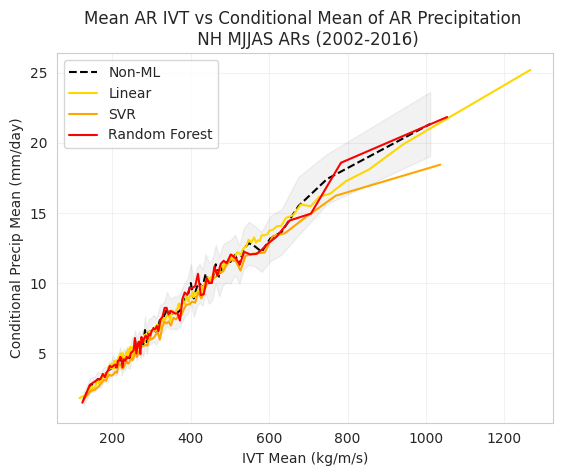

In [43]:
## Scatterplot for MJJAS ARs
# Non-ML
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean, color = 'black', label = 'Non-ML', ls = '--')
plt.fill_between(AR_NH_MJJAS_IVT_precip_conditional_mean['AR Mean IVT (kg/m/s)'],
                 AR_NH_MJJAS_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_MJJAS_IVT_precip_conditional_mean['ci'],
                 AR_NH_MJJAS_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] + AR_NH_MJJAS_IVT_precip_conditional_mean['ci'],
                 color = 'black', alpha = 0.05)

# Linear Model
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean_lin, color = 'gold', label = 'Linear')

# SVR
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean_SVR, color = 'orange', label = 'SVR')

# Random Forest
sns.lineplot(x = 'AR Mean IVT (kg/m/s)', y = 'AR Mean Precip (mm/day)',
                data = AR_NH_MJJAS_IVT_precip_conditional_mean_rf, color = 'red', label = 'Random Forest')


plt.legend()
plt.xlabel('IVT Mean (kg/m/s)'), plt.ylabel('Conditional Precip Mean (mm/day)')
plt.grid(alpha = 0.25)
#plt.xlim(0, 1500), plt.ylim(0, 30)
#plt.xticks([0, 250, 500, 750, 1000, 1250, 1500])
plt.title('Mean AR IVT vs Conditional Mean of AR Precipitation \n NH MJJAS ARs (2002-2016)')


plt.show()

In [35]:
# If we take the Non-ML as the "ground truth"
print('NDJFM AR Results')
print("RMSE for Linear Regression:", np.sqrt(np.mean((AR_NH_NDJFM_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean_lin['AR Mean Precip (mm/day)'])**2)))
print("RMSE for SVR:", np.sqrt(np.mean((AR_NH_NDJFM_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean_SVR['AR Mean Precip (mm/day)'])**2)))
print("RMSE for Random Forest Regression:", np.sqrt(np.mean((AR_NH_NDJFM_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_NDJFM_IVT_precip_conditional_mean_rf['AR Mean Precip (mm/day)'])**2)))
print('\n')
print('MJJAS AR Results')
print("RMSE for Linear Regression:", np.sqrt(np.mean((AR_NH_MJJAS_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_MJJAS_IVT_precip_conditional_mean_lin['AR Mean Precip (mm/day)'])**2)))
print("RMSE for SVR:", np.sqrt(np.mean((AR_NH_MJJAS_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_MJJAS_IVT_precip_conditional_mean_SVR['AR Mean Precip (mm/day)'])**2)))
print("RMSE for Random Forest Regression:", np.sqrt(np.mean((AR_NH_MJJAS_IVT_precip_conditional_mean['AR Mean Precip (mm/day)'] - AR_NH_MJJAS_IVT_precip_conditional_mean_rf['AR Mean Precip (mm/day)'])**2)))

NDJFM AR Results
RMSE for Linear Regression: 3.640308697847105
RMSE for SVR: 2.8513412351917755
RMSE for Random Forest Regression: 0.8942108011380351


MJJAS AR Results
RMSE for Linear Regression: 4.4334539814334
RMSE for SVR: 0.9231731756942404
RMSE for Random Forest Regression: 1.5259688084302796
